## Data reading
* use tiff stack
* take first section of imaging (20 s) as background mean
* calculate smoothed $\Delta F_t/F_0$

In [1]:
# ==========================================
# PROCESSING SCRIPT (RUN ONCE)
# ==========================================

import numpy as np
import tifffile as tiff
from scipy.ndimage import gaussian_filter
import os

# -------- USER SETTINGS --------
path = "Baseline_Gcamp8s_mea_mesh_50uA 10ms 20 hz all electrodes_0010.tif"
is_stack = True

total_duration = 120
f0_duration = 20
smooth_sigma = 1
clip_negative = True

output_file = "processed_full_delta_stack.npz"
# --------------------------------

# Load data
if is_stack:
    data = tiff.imread(path)
else:
    files = sorted([f for f in os.listdir(path)
                    if f.endswith(".tif") or f.endswith(".tiff")])
    data = np.array([tiff.imread(os.path.join(path, f)) for f in files])

n_frames, h, w = data.shape
fps = n_frames / total_duration

print("Computing F0...")
f0_frames = int(fps * f0_duration)
F0 = np.mean(data[:f0_frames], axis=0)
F0[F0 == 0] = 1e-6

print("Computing ΔF/F0 for all frames after baseline...")
start_frame = f0_frames
delta_stack = []

for idx in range(start_frame, n_frames):
    Ft = data[idx]
    delta = (Ft - F0) / F0

    if smooth_sigma > 0:
        delta = gaussian_filter(delta, sigma=smooth_sigma)

    if clip_negative:
        delta[delta < 0] = 0

    delta_stack.append(delta)

delta_stack = np.array(delta_stack)

print("Saving...")
np.savez_compressed(
    output_file,
    delta_stack=delta_stack,
    fps=fps
)

print("Done.")


Computing F0...
Computing ΔF/F0 for all frames after baseline...
Saving...
Done.


## Wavefront map

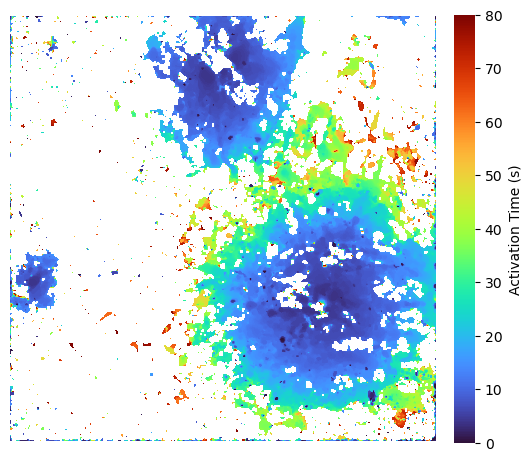

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, gaussian_filter1d

# ======================================================
# USER PARAMETERS
# ======================================================

start_time_seconds = 0          # NEW: analysis window start
max_time_seconds   = 80          # analysis window end

activation_threshold = 0.1
spatial_sigma = 2
temporal_sigma = 1
signal_cutoff = 0.05

# delta_stack and fps must already exist
# delta_stack shape = (frames, height, width)

# ======================================================
# 1️⃣ CROP TIME WINDOW (START + END)
# ======================================================

start_frame = int(start_time_seconds * fps)
end_frame   = int(max_time_seconds * fps)

# Clamp to valid range
start_frame = max(0, start_frame)
end_frame   = min(delta_stack.shape[0], end_frame)

delta_subset = delta_stack[start_frame:end_frame]

# ======================================================
# 2️⃣ SPATIAL SMOOTHING
# ======================================================

delta_smooth = np.array([
    gaussian_filter(frame, sigma=spatial_sigma)
    for frame in delta_subset
])

# ======================================================
# 3️⃣ TEMPORAL SMOOTHING
# ======================================================

delta_smooth = gaussian_filter1d(delta_smooth, sigma=temporal_sigma, axis=0)

# ======================================================
# 4️⃣ GLOBAL NORMALIZATION (within window)
# ======================================================

max_val = np.max(delta_smooth)
if max_val > 0:
    delta_smooth /= max_val

# ======================================================
# 5️⃣ REMOVE LOW-SIGNAL BACKGROUND
# ======================================================

signal_mask = np.max(delta_smooth, axis=0) > signal_cutoff

# ======================================================
# 6️⃣ COMPUTE ACTIVATION TIME MAP
# ======================================================

n_frames, h, w = delta_smooth.shape
activation_map = np.full((h, w), np.nan)

for t in range(n_frames):
    newly_active = (
        (delta_smooth[t] > activation_threshold) &
        signal_mask &
        np.isnan(activation_map)
    )
    activation_map[newly_active] = t

# Convert to ABSOLUTE time (seconds)
activation_map_seconds = (activation_map + start_frame) / fps

# ======================================================
# 7️⃣ PLOT ACTIVATION MAP (TRANSPARENT EXPORT)
# ======================================================

cmap = plt.cm.turbo.copy()
cmap.set_bad(color=(1,1,1,0))  # transparent for NaN

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

activation_masked = np.ma.masked_invalid(activation_map_seconds)

im = ax.imshow(
    activation_masked,
    cmap=cmap,
    vmin=start_time_seconds,
    vmax=max_time_seconds
)

ax.axis('off')

cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Activation Time (s)")
cbar.outline.set_visible(False)

# Force full render (important in VSCode)
fig.canvas.draw()

# Save transparent PNG
fig.savefig(
    "activation_wave_map_transparent.png",
    dpi=600,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0
)

plt.show()


C:\Users\97054\AppData\Local\Temp\ipykernel_9856\3045061501.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('viridis')


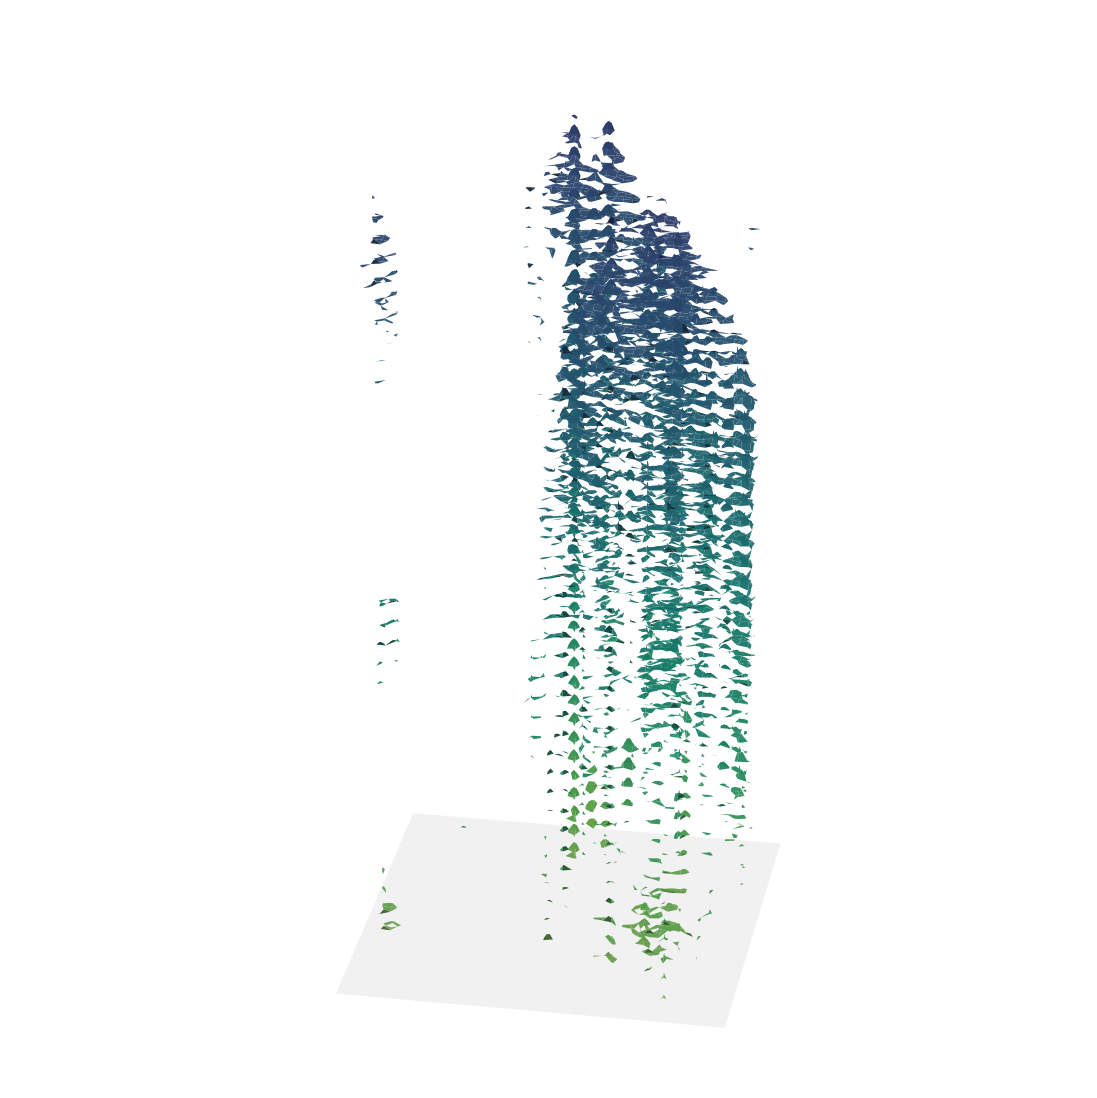

In [3]:
# ======================================================
# 8️⃣ CLEAN 3D STACKED INTENSITY PLOT (GRADIENT + AXES)
# ======================================================

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.colors as mcolors

# ---------------- USER CONTROLS ----------------
stack_start_sec = 0
stack_end_sec = 80

layer_spacing_seconds = 2
layer_offset_distance = 2

layer_height_scale = 2
height_threshold = 0.1
clip_percentile = 99
downsample = 4

z_aspect_ratio = 2
# ------------------------------------------------

# Convert seconds to frames
start_frame = int(stack_start_sec * fps)
end_frame = int(stack_end_sec * fps)
step_frames = int(layer_spacing_seconds * fps)

n_available_frames = delta_smooth.shape[0]
start_frame = max(0, start_frame)
end_frame = min(n_available_frames, end_frame)
step_frames = max(1, step_frames)

frames_to_plot = np.arange(start_frame, end_frame, step_frames)

h, w = delta_smooth.shape[1:]
Y, X = np.mgrid[0:h, 0:w]

X = X[::downsample, ::downsample]
Y = Y[::downsample, ::downsample]

fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(111, projection='3d')

n_layers = len(frames_to_plot)

# ---------- Nature-style gradient ----------
# Use a trimmed viridis (avoid yellow top)
base_cmap = cm.get_cmap('viridis')
colors = [base_cmap(0.2 + 0.6*i/(n_layers-1)) for i in range(n_layers)]
# -------------------------------------------

for i, t in enumerate(frames_to_plot):

    intensity = delta_smooth[t].copy()

    intensity[intensity < height_threshold] = np.nan
    max_allowed = np.nanpercentile(intensity, clip_percentile)
    intensity = np.clip(intensity, 0, max_allowed)

    intensity = intensity[::downsample, ::downsample]

    layer_offset = (n_layers - 1 - i) * layer_offset_distance
    Z = intensity * layer_height_scale + layer_offset

    ax.plot_surface(
        X,
        Y,
        Z,
        color=colors[i],
        linewidth=0,
        antialiased=True,
        alpha=0.95
    )

# ---------- Bottom reference plane ----------
Z_base = np.zeros_like(X)

ax.plot_surface(
    X,
    Y,
    Z_base,
    color='lightgray',
    alpha=0.15,
    linewidth=0
)

# ---------- Clean axes ----------
ax.set_xlabel("X (pixels)", labelpad=20)
ax.set_ylabel("Y (pixels)", labelpad=20)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Remove Z ticks for cleaner look
ax.set_zticks([])

# Remove grid but keep axes
ax.grid(False)

# Remove pane fill but keep axis lines
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# Turn off axis lines, ticks, labels
ax.set_axis_off()

# Remove pane backgrounds (XY, YZ, ZX planes)
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)

ax.set_box_aspect([1, 1, z_aspect_ratio])

# perspective adjustment
ax.view_init(elev=25, azim=-80)

ax.invert_yaxis()

plt.show()

# Force full render
fig.canvas.draw()

# Save transparent PNG
fig.savefig(
    "3D_wave_stack_transparent.png",
    dpi=600,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0
)

plt.show()


